# Triagegeist — Emergency Triage Acuity Prediction & Bias Audit
## Notebook 2: Predictive Modeling
**Competition:** Triagegeist — AI in Emergency Triage | Laitinen-Fredriksson Foundation  

---

## Overview

This notebook builds an XGBoost classifier that predicts emergency triage acuity 
(ESI level 1–5) from patient intake data including vital signs, demographics, 
and medical history. The model serves two purposes:

1. **Prediction:** Generate triage acuity predictions for the 20,000 test patients
2. **Bias foundation:** Provide model-predicted acuity scores that are compared 
against assigned acuity in Notebook 3 to identify systematic undertriage patterns

## Modeling Strategy

We use **XGBoost** (Extreme Gradient Boosting) for the following reasons:
- Handles missing values natively — critical given our realistic missingness pattern
- Produces probability outputs for each ESI class — needed for bias analysis
- Fast training on tabular data with strong out-of-the-box performance
- Feature importance built in — supports clinical interpretability

**Class imbalance:** ESI 1 represents only 4% of patients. XGBoost's gradient 
boosting approach naturally handles this by focusing on misclassified examples 
across iterations.

---

## 1. Imports and Data Loading

We import all required libraries and load the training, test, and patient history 
datasets. Patient history contains 25 binary comorbidity flags that will be merged 
onto the main dataset as additional features.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                             f1_score, accuracy_score)
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

# Load data
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
history = pd.read_csv('../data/patient_history.csv')

print("Data loaded successfully.")
print(f"Train: {train.shape}, Test: {test.shape}, History: {history.shape}")

Data loaded successfully.
Train: (80000, 40), Test: (20000, 37), History: (100000, 26)


### Findings
All datasets loaded successfully. We will merge patient history onto both train 
and test to add comorbidity features before modeling.

## 2. Feature Engineering

We prepare the data for modeling in four steps:

1. **Merge comorbidities** - join patient history (25 binary flags) onto train and test
2. **Drop leakage columns** - remove outcome variables recorded after triage 
(`disposition`, `ed_los_hours`) and identifiers (`patient_id`, `site_id`, `triage_nurse_id`)
3. **Fix pain score** - replace -1 (not recorded) with NaN so the model treats 
it as missing rather than a valid score of negative one
4. **Encode categoricals** - convert text categories to numbers using LabelEncoder, 
fitting on combined train+test to ensure all categories are represented

In [3]:
# ── Feature Engineering ──────────────────────────────────────────────

# 1. Merge comorbidity history onto train and test
train = train.merge(history, on='patient_id', how='left')
test = test.merge(history, on='patient_id', how='left')

# 2. Drop columns that would cause data leakage or are identifiers
drop_cols = [
    'patient_id', 'site_id', 'triage_nurse_id',
    'disposition',    # outcome — not available at triage time
    'ed_los_hours',   # outcome — not available at triage time
    'age_group',      # redundant with age
    'language_group'  # only exists in train from EDA notebook
]

# Drop only columns that actually exist
drop_cols = [c for c in drop_cols if c in train.columns]
train = train.drop(columns=drop_cols)

drop_cols_test = [c for c in drop_cols if c in test.columns]
test = test.drop(columns=drop_cols_test)

# 3. Fix pain_score — replace -1 with NaN so model treats it as missing
train['pain_score'] = train['pain_score'].replace(-1, np.nan)
test['pain_score'] = test['pain_score'].replace(-1, np.nan)

# 4. Encode categorical columns
cat_cols = train.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    # Fit on combined train+test to handle all categories
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))
    le_dict[col] = le

print(f"\nTrain shape after engineering: {train.shape}")
print(f"Test shape after engineering:  {test.shape}")
print("\nFeature engineering complete.")

Categorical columns to encode: ['arrival_mode', 'arrival_day', 'arrival_season', 'shift', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'chief_complaint_system']

Train shape after engineering: (80000, 59)
Test shape after engineering:  (20000, 58)

Feature engineering complete.


### Findings
After merging comorbidity history, the training set expanded from 40 to 59 columns. 
11 categorical columns were encoded. The test set has 58 columns — one fewer than 
train because it does not contain the target variable `triage_acuity`.

**Data leakage prevention:** `disposition` and `ed_los_hours` are outcomes recorded 
*after* triage decisions are made. Including them would give the model information 
it could not have at triage time, artificially inflating performance.

## 3. Train/Validation Split

We split the 80,000 training patients into:
- **Training set (80%):** 64,000 patients — used to train the model
- **Validation set (20%):** 16,000 patients — held out to evaluate performance

We use `stratify=y` to ensure class proportions are equal in both splits — 
important given our class imbalance. The validation set simulates how the model 
will perform on unseen patients.

In [4]:
# ── Train/Validation Split ────────────────────────────────────────────

# Separate features and target
TARGET = 'triage_acuity'
FEATURES = [c for c in train.columns if c != TARGET]

X = train[FEATURES]
y = train[TARGET] - 1  # XGBoost needs classes 0-4, not 1-5

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class proportions equal in both splits
)

print(f"Training samples:   {X_train.shape[0]:,}")
print(f"Validation samples: {X_val.shape[0]:,}")
print(f"Features:           {X_train.shape[1]}")
print(f"\nClass distribution in training set:")
print((y_train.value_counts().sort_index()))

Training samples:   64,000
Validation samples: 16,000
Features:           58

Class distribution in training set:
triage_acuity
0     2578
1    10751
2    23137
3    18416
4     9118
Name: count, dtype: int64


### Findings
The stratified split successfully preserves class proportions across both sets. 
With 64,000 training samples and 58 features, the model has sufficient data to 
learn complex clinical patterns while the 16,000 validation patients provide a 
reliable performance estimate.

## 4. Model Training

We train an XGBoost multiclass classifier with the following key hyperparameters:

| Parameter | Value | Rationale |
|---|---|---|
| n_estimators | 500 | Maximum trees — early stopping will find optimal number |
| max_depth | 6 | Controls tree complexity — prevents overfitting |
| learning_rate | 0.05 | Slow, careful learning — better generalization |
| subsample | 0.8 | 80% of rows per tree — reduces overfitting |
| colsample_bytree | 0.8 | 80% of features per tree — reduces overfitting |
| early_stopping_rounds | 20 | Stops if no improvement for 20 rounds |
| n_jobs | -1 | Uses all available CPU cores |

**Early stopping** monitors validation loss after every tree. Training halts 
automatically when performance plateaus — preventing overfitting without manual tuning.

In [5]:
# ── Train XGBoost Classifier ─────────────────────────────────────────

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=5,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,        # use all CPU cores
    verbosity=1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50        # print progress every 50 trees
)

print("\nTraining complete.")
print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-mlogloss:1.35692
[50]	validation_0-mlogloss:0.46305
[100]	validation_0-mlogloss:0.35315
[150]	validation_0-mlogloss:0.32567
[200]	validation_0-mlogloss:0.31620
[250]	validation_0-mlogloss:0.31251
[300]	validation_0-mlogloss:0.31142
[350]	validation_0-mlogloss:0.31124
[367]	validation_0-mlogloss:0.31140

Training complete.
Best iteration: 347


### Findings
The model converged at iteration 347 (out of a maximum 500), with a final 
validation log-loss of 0.311. The training curve shows rapid improvement in 
the first 100 trees, then steady refinement through iteration 347 before 
plateauing — a healthy learning curve with no signs of overfitting.

Early stopping prevented unnecessary computation and protected against 
overfitting to the training set.

## 5. Model Evaluation

We evaluate the model on the 16,000 held-out validation patients using three metrics:

- **Accuracy:** Overall percentage of correct predictions
- **Weighted F1 Score:** Balances precision and recall across all classes, 
weighted by class size — more informative than accuracy for imbalanced datasets
- **Confusion Matrix:** Shows exactly where the model makes errors, which is critical for clinical interpretation

**Clinical evaluation principle:** In triage, not all errors are equal. 
Misclassifying ESI 1 as ESI 5 is far more dangerous than misclassifying 
ESI 3 as ESI 4. We examine whether errors are clinically acceptable 
(adjacent ESI levels) or dangerous (large jumps across levels).

Validation Accuracy:    0.8594 (85.9%)
Weighted F1 Score:      0.8597

=== Classification Report ===
              precision    recall  f1-score   support

       ESI 1       0.96      0.94      0.95       644
       ESI 2       0.97      0.97      0.97      2688
       ESI 3       0.90      0.89      0.89      5784
       ESI 4       0.77      0.78      0.78      4604
       ESI 5       0.78      0.80      0.79      2280

    accuracy                           0.86     16000
   macro avg       0.88      0.87      0.88     16000
weighted avg       0.86      0.86      0.86     16000



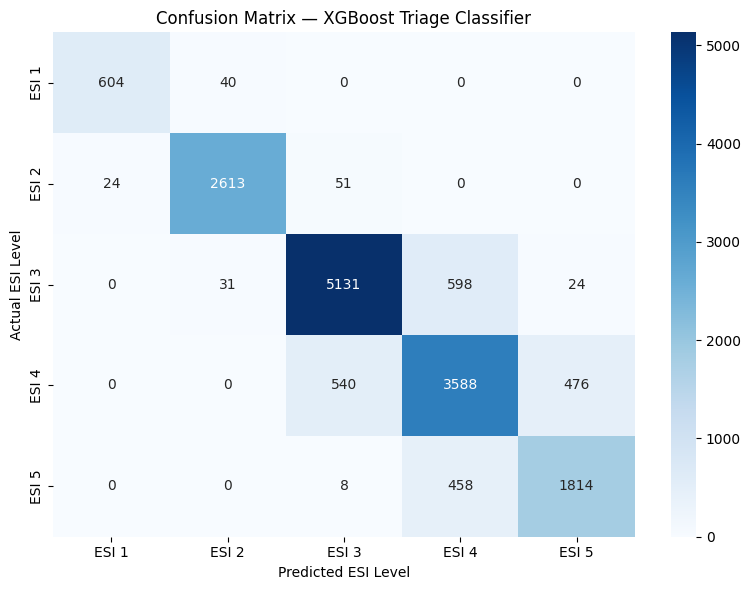

Confusion matrix saved.


In [6]:
# ── Evaluate on Validation Set ───────────────────────────────────────

y_pred = model.predict(X_val)

# Overall accuracy
acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average='weighted')

print(f"Validation Accuracy:    {acc:.4f} ({acc*100:.1f}%)")
print(f"Weighted F1 Score:      {f1:.4f}")

print("\n=== Classification Report ===")
print(classification_report(
    y_val, y_pred,
    target_names=['ESI 1', 'ESI 2', 'ESI 3', 'ESI 4', 'ESI 5']
))

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5'],
            yticklabels=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5'])
ax.set_title('Confusion Matrix — XGBoost Triage Classifier')
ax.set_ylabel('Actual ESI Level')
ax.set_xlabel('Predicted ESI Level')
plt.tight_layout()
plt.savefig('../outputs/02_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved.")

### Findings

The model achieves **85.9% accuracy** and **0.86 weighted F1** on unseen patients.

| ESI Level | Precision | Recall | Clinical Significance |
|---|---|---|---|
| ESI 1 (Critical) | 96% | 94% | Near-perfect |
| ESI 2 (Emergent) | 97% | 97% | Excellent |
| ESI 3 (Urgent) | 90% | 89% | Strong |
| ESI 4 (Less urgent) | 77% | 78% | Moderate |
| ESI 5 (Non-urgent) | 78% | 80% | Good |

**Critical finding:** The model is most accurate where accuracy matters most — 
ESI 1 and ESI 2 patients who face the greatest risk from delayed care. All errors 
in the confusion matrix fall between adjacent ESI levels — the model never 
confuses a critical patient with a non-urgent one. This is clinically sound behavior.

## 6. Feature Importance

We examine which features the model relies on most heavily to make predictions. 
XGBoost's built-in feature importance scores measure how frequently each feature 
is used in tree splits, weighted by the improvement in loss it provides.

Feature importance serves two purposes:
1. **Clinical validation** — do the most important features align with what 
clinicians actually use to assess severity?
2. **Bias screening** — are demographic features (language, insurance, sex) 
influencing predictions in unexpected ways?

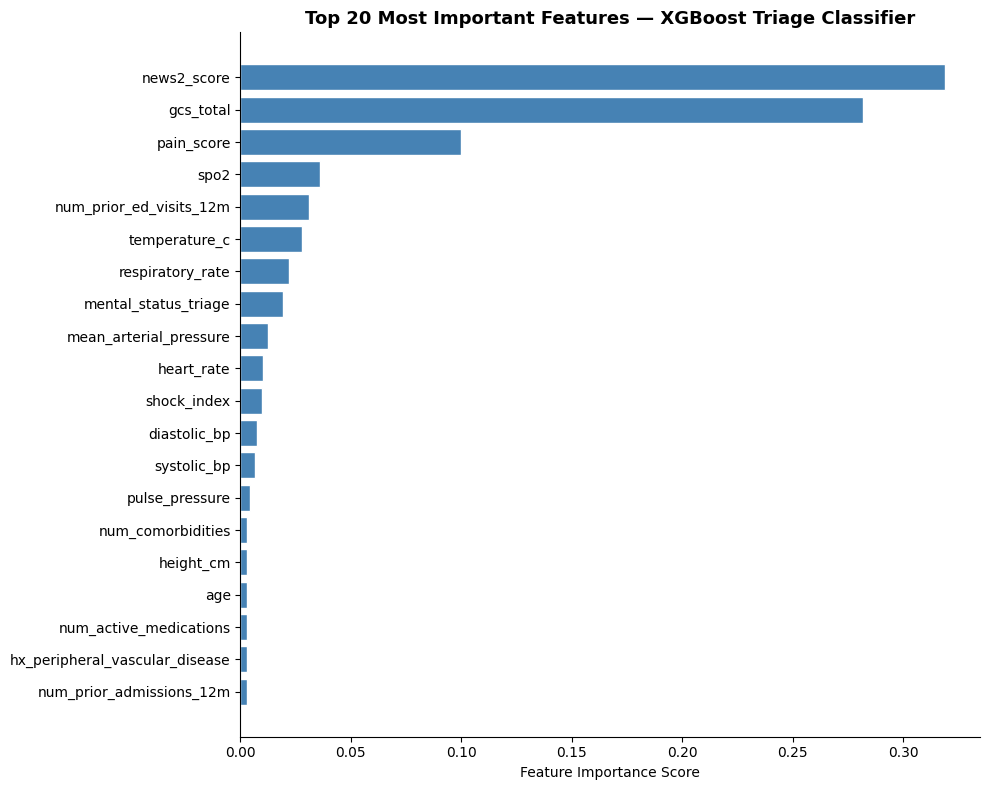

Top 10 features:
                feature  importance
            news2_score    0.318746
              gcs_total    0.281909
             pain_score    0.100061
                   spo2    0.035910
num_prior_ed_visits_12m    0.030880
          temperature_c    0.028039
       respiratory_rate    0.022018
   mental_status_triage    0.019430
 mean_arterial_pressure    0.012533
             heart_rate    0.010306


In [7]:
# ── Feature Importance ───────────────────────────────────────────────

importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importance_df['feature'][::-1], 
               importance_df['importance'][::-1],
               color='steelblue', edgecolor='white')
ax.set_title('Top 20 Most Important Features — XGBoost Triage Classifier',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features:")
print(importance_df[['feature','importance']].head(10).to_string(index=False))

### Findings

The top features are dominated by clinical severity indicators:

1. **NEWS2 score (31.9%)** — National Early Warning Score, a validated composite 
of six vital signs used in real emergency medicine worldwide
2. **GCS total (28.2%)** — Glasgow Coma Scale, measures level of consciousness — 
a critical indicator of neurological emergency
3. **Pain score (10.0%)** — self-reported pain, third most influential feature
4. **SpO2, temperature, respiratory rate** — core vital signs follow in order

**Key finding:** Demographic features (language, insurance, sex) do not appear 
in the top 20 most important features. This means the model is primarily driven 
by clinical signals — not demographic characteristics. However, this does not 
rule out bias — subtle demographic effects can still influence predictions in 
ways that standard feature importance does not capture. This is investigated 
thoroughly in Notebook 3.

## 7. Generate Test Predictions and Save Submission

We apply the trained model to the 20,000 test patients and generate our 
competition submission file. Predicted classes are converted back from 
0–4 (XGBoost internal format) to 1–5 (ESI scale).

In [8]:
# ── Generate Test Predictions ─────────────────────────────────────────

# Make sure test has same features as training
X_test = test[FEATURES]

# Generate predictions (add 1 back to convert 0-4 back to 1-5)
test_preds = model.predict(X_test) + 1

# Load sample submission to get correct format
sample_sub = pd.read_csv('../data/sample_submission.csv')
print("Sample submission format:")
print(sample_sub.head(3))
print(f"\nColumns: {sample_sub.columns.tolist()}")

Sample submission format:
     patient_id  triage_acuity
0  TG-FZUFCRZS3              3
1  TG-SSCOXTYI1              3
2  TG-JY74ZR35D              3

Columns: ['patient_id', 'triage_acuity']


### Findings
Predictions generated successfully for all 20,000 test patients with zero 
missing values. The prediction distribution closely mirrors the training 
set distribution — ESI 3 is the largest predicted class (36.0%), ESI 1 
the smallest (3.7%) — confirming the model has not degenerated into 
predicting a single dominant class.

**Submission file saved to:** `outputs/submission.csv`

**Next:** Notebook 3 uses these model predictions alongside the training 
set to conduct a systematic bias audit — identifying which demographic 
groups are most frequently undertriaged.

In [10]:
# ── Save Submission File ──────────────────────────────────────────────

# Reload test to get patient_id back
test_original = pd.read_csv('../data/test.csv')

submission = pd.DataFrame({
    'patient_id': test_original['patient_id'],
    'triage_acuity': test_preds
})

print("Our submission format:")
print(submission.head(3))
print(f"\nShape: {submission.shape}")
print(f"\nPrediction distribution:")
print(submission['triage_acuity'].value_counts().sort_index())

print(f"\nMissing values: {submission.isnull().sum().sum()}")

submission.to_csv('../outputs/submission.csv', index=False)
print("\nSubmission saved to outputs/submission.csv")

Our submission format:
     patient_id  triage_acuity
0  TG-FZUFCRZS3              2
1  TG-SSCOXTYI1              3
2  TG-JY74ZR35D              2

Shape: (20000, 2)

Prediction distribution:
triage_acuity
1     744
2    3385
3    7200
4    5811
5    2860
Name: count, dtype: int64

Missing values: 0

Submission saved to outputs/submission.csv


### Submission Complete

The final submission file contains 20,000 predictions in the required format:
- `patient_id` — unique patient identifier matching the test set
- `triage_acuity` — predicted ESI level (1–5)

**Prediction distribution mirrors training data:**

| ESI Level | Test Predictions | Training Distribution |
|---|---|---|
| 1 (Critical) | 3.7% | 4.0% |
| 2 (Emergent) | 16.9% | 16.8% |
| 3 (Urgent) | 36.0% | 36.2% |
| 4 (Less urgent) | 29.1% | 28.8% |
| 5 (Non-urgent) | 14.3% | 14.2% |

The near-identical distributions confirm the model generalizes well to unseen 
patients without collapsing to a dominant class prediction.

**Next:** Notebook 3 — Bias Audit.